In [3]:
!python --version

Python 3.10.12


In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
%cd /workspace/ViCLIP-OT

/workspace/ViCLIP-OT


## Import libraries

In [32]:
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import scienceplots  # noqa: F401
import seaborn as sns
import torch
import torchvision.transforms.v2 as v2
import umap
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from tqdm.autonotebook import tqdm

import viclip_ot.constants as C
import viclip_ot.utils as utils
from viclip_ot.dataset import ImageTextDataset
from viclip_ot.model import ViCLIPOT, ViCLIPOTConfig
from viclip_ot.utils.logger import logger

## Config

In [43]:
SEED = 42
DATASET_DIR = "./data/UIT-OpenViIC"
TEST_SPLIT_NAME = "test"
MODEL_CONFIG_FILE = "./config/model.vit_base_dinov3_sbert_siglip.yaml"
# FROM_CHECKPOINT = "./checkpoints/2026-01-30_01-08-48-ablation_sbert-siglip_loss_lambda_0.1/model_epoch_29_t2i_R__1_0.4151.pth"
FROM_CHECKPOINT = "./checkpoints/2026-01-29_22-30-24-ablation_sbert-siglip_loss_only-fixed_multiple_caps-scale_0.06-bias_-9/model_epoch_27_t2i_R__1_0.3744.pth"
DEVICE = "auto"

## Loading model

In [44]:
utils.set_seed(SEED)
device = utils.get_device(DEVICE)
print(f"Using device: {device}")

Using device: cuda


In [45]:
model_config = ViCLIPOTConfig.model_validate(utils.load_yaml_file(MODEL_CONFIG_FILE))
print(f"Model config: {model_config}")
model = ViCLIPOT(config=model_config)
tokenizer = model.text_encoder.tokenizer
model.to(device).eval()
print(f"{model.training}")

Model config: image_config=ViCLIPOTImageConfig(model_name='timm/vit_base_patch16_dinov3.lvd1689m', pretrained=True, pool='avg', proj='linear', proj_bias=False, proj_dropout_rate=0.1) text_config=ViCLIPOTTextConfig(model_name='keepitreal/vietnamese-sbert', pretrained=True, proj='none', proj_bias=False) embed_dim=768 initial_temperature=0.06 logit_bias=-9.0
False


In [46]:
logger.info(f"Loading model from checkpoint: {FROM_CHECKPOINT}")
checkpoint = torch.load(FROM_CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"], strict=True)

2026-02-01 13:34:33.556 | INFO     | __main__:<module>:1 - Loading model from checkpoint: ./checkpoints/2026-01-29_22-30-24-ablation_sbert-siglip_loss_only-fixed_multiple_caps-scale_0.06-bias_-9/model_epoch_27_t2i_R__1_0.3744.pth


<All keys matched successfully>

## Loading test data

In [47]:
eval_transforms = v2.Compose(
    [
        v2.Resize(size=256, interpolation=v2.InterpolationMode.BICUBIC),
        v2.CenterCrop(size=224),
        v2.ToTensor(),
        v2.Normalize(
            mean=C.IMAGENET_DEFAULT_MEAN,
            std=C.IMAGENET_DEFAULT_STD,
        ),
    ]
)


def model_fmt() -> Literal["gemma", "e5", "qwen3", "bge", "sbert"]:
    model_name = model_config.text_config.model_name
    if "gemma" in model_name.lower():  # google/embeddinggemma-300m
        return "gemma"
    elif "e5" in model_name.lower():  # intfloat/multilingual-e5-large
        return "e5"
    elif "qwen" in model_name.lower():  # Qwen/Qwen3-Embedding-0.6B
        return "qwen3"
    elif "bge" in model_name.lower():  # BAAI/bge-m3
        return "bge"
    elif "sbert" in model_name.lower():  # keepitreal/vietnamese-sbert
        return "sbert"
    else:
        raise ValueError(f"Unsupported model name for determining model format: {model_name}")


logger.info(f"Determined model format: {model_fmt()}")

test_dataset = ImageTextDataset(
    root_dir=DATASET_DIR,
    metadata_json_file=f"{TEST_SPLIT_NAME}.json",
    image_transforms=eval_transforms,
    model_fmt=model_fmt(),
)

/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
2026-02-01 13:34:35.081 | INFO     | __main__:<module>:30 - Determined model format: sbert
2026-02-01 13:34:35.082 | INFO     | viclip_ot.dataset:__init__:77 - Loading image text data from: ./data/UIT-OpenViIC/test.json
2026-02-01 13:34:35.117 | INFO     | viclip_ot.dataset:__init__:81 - Found 2001 images and 10001 annotations.


## Computing embeddings

### Image embeddings

In [48]:
all_image_features = []
all_text_features = []
batch_size = 32
with torch.no_grad():
    progress_bar = tqdm(range(0, len(test_dataset), batch_size), "Embedding images")
    for start_idx in progress_bar:
        end_idx = min(len(test_dataset), start_idx + batch_size)

        images = []
        texts = []
        for j in range(start_idx, end_idx):
            sample = test_dataset[j]
            images.append(sample[0])
            texts.append(sample[1][0])  # take the first caption only

        images = torch.stack(images).to(device)
        texts = tokenizer(
            texts, padding=True, truncation=True, max_length=1024, return_tensors="pt"
        ).to(device)

        image_features = model.encode_image(images, normalize=True)
        text_features = model.encode_text(texts, normalize=True)

        all_image_features.append(image_features.cpu())
        all_text_features.append(text_features.cpu())

    all_image_features = torch.cat(all_image_features, dim=0)
    all_text_features = torch.cat(all_text_features, dim=0)

print(f"{all_image_features.shape = }")
print(f"{all_text_features.shape = }")

Embedding images:   0%|          | 0/63 [00:00<?, ?it/s]

2026-02-01 13:35:16.884 | WARNING  | viclip_ot.dataset:__getitem__:141 - Corrupt image at ./data/UIT-OpenViIC/./images/00000005095.jpg, skipping. Error: image file is truncated (76 bytes not processed)
2026-02-01 13:35:24.341 | WARNING  | viclip_ot.dataset:__getitem__:141 - Corrupt image at ./data/UIT-OpenViIC/./images/00000001010.jpg, skipping. Error: image file is truncated (155 bytes not processed)
2026-02-01 13:35:24.904 | WARNING  | viclip_ot.dataset:__getitem__:141 - Corrupt image at ./data/UIT-OpenViIC/./images/00000000768.jpg, skipping. Error: image file is truncated (18 bytes not processed)


all_image_features.shape = torch.Size([2001, 768])
all_text_features.shape = torch.Size([2001, 768])


In [49]:
def visualize_embeddings(
    image_embeddings, text_embeddings=None, num_clusters: int = 20, num_samples: int = 4_000
):
    """
    Args:
        image_embeddings: Numpy array (N, D)
        text_embeddings: Numpy array (N, D)
        num_clusters: How many 'concepts' to discover (K-Means)
        num_samples: Limit data size for t-SNE speed (t-SNE is slow > 5k points)
    """

    # ---------------------------------------------------------
    # 1. SAMPLING
    # t-SNE is computationally expensive. Sample N pairs randomly.
    # ---------------------------------------------------------
    total_samples = image_embeddings.shape[0]
    if total_samples > num_samples:
        indices = np.random.choice(total_samples, num_samples, replace=False)
        img_emb = image_embeddings[indices]
        txt_emb = text_embeddings[indices] if text_embeddings is not None else None
    else:
        img_emb = image_embeddings
        txt_emb = text_embeddings

    # ---------------------------------------------------------
    # 2. NORMALIZATION (Crucial Best Practice!)
    # CLIP/Dual-Encoders use Cosine Similarity. t-SNE uses Euclidean.
    # Normalizing vectors to length 1 makes Euclidean distance
    # proportional to Cosine distance.
    # ---------------------------------------------------------
    img_emb = normalize(img_emb, axis=1, norm="l2")
    if txt_emb is not None:
        txt_emb = normalize(txt_emb, axis=1, norm="l2")

    # ---------------------------------------------------------
    # 3. GENERATE PSEUDO-LABELS (The Macro View)
    # We cluster the IMAGES. We assume the Text *should* belong
    # to the same cluster as its paired image.
    # ---------------------------------------------------------
    print(f"Running K-Means (k={num_clusters}) to generate pseudo-labels...")
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    # Fit only on images (they usually contain more robust features)
    cluster_labels = kmeans.fit_predict(img_emb)

    # ---------------------------------------------------------
    # 4. PREPARE FOR t-SNE
    # Stack images and texts together to map them into the same 2D space
    # ---------------------------------------------------------
    if txt_emb is not None:
        combined_emb = np.vstack([img_emb, txt_emb])
    else:
        combined_emb = img_emb

    # Create labels for the plot
    # 0 = Image, 1 = Text
    modality_labels = np.array(
        [0] * len(img_emb) + [1] * len(txt_emb) if txt_emb is not None else [0] * len(img_emb)
    )

    # Duplicate the cluster labels (Image i is cluster A -> Text i is also cluster A)
    combined_cluster_labels = (
        np.concatenate([cluster_labels, cluster_labels]) if txt_emb is not None else cluster_labels
    )

    # ---------------------------------------------------------
    # 5. RUN t-SNE
    # perplexity=30 is standard. learning_rate='auto' is usually best.
    # ---------------------------------------------------------
    print("Running t-SNE (this might take a moment)...")
    # tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
    tsne = umap.UMAP(
        n_neighbors=30,
        n_components=2,
        metric="euclidean",
        n_epochs=500,
        random_state=42,
        init="pca",
        learning_rate=1.0,
        verbose=True,
    )
    tsne_results = tsne.fit_transform(combined_emb)

    # ---------------------------------------------------------
    # 6. PLOTTING
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 10))

    # We use a distinct color palette for the clusters
    palette = sns.color_palette("tab10", num_clusters)

    # Plot Images (Circles)
    sns.scatterplot(
        x=tsne_results[modality_labels == 0, 0],
        y=tsne_results[modality_labels == 0, 1],
        hue=combined_cluster_labels[modality_labels == 0],
        palette=palette,
        style=None,
        marker="o",  # Circle for Image
        s=80,  # Size
        alpha=0.6,  # Transparency
        edgecolor="w",
        legend=False,  # Hide legend for now to avoid clutter
    )

    # Plot Texts (Triangles)
    sns.scatterplot(
        x=tsne_results[modality_labels == 1, 0],
        y=tsne_results[modality_labels == 1, 1],
        hue=combined_cluster_labels[modality_labels == 1],
        palette=palette,
        style=None,
        marker="^",  # Triangle for Text
        s=100,  # Slightly larger for text
        alpha=0.8,  # More opaque
        edgecolor="k",
        legend="full",
    )

    plt.title(
        "t-SNE of Image-Text Embeddings\n(Colors = K-Means Pseudo-Classes from Images)",
        fontsize=16,
    )
    plt.grid(True, linestyle="--", alpha=0.3)

    # Custom Legend
    from matplotlib.lines import Line2D

    custom_lines = [
        Line2D(
            [0], [0], marker="o", color="w", markerfacecolor="gray", markersize=10, label="Image"
        ),
        Line2D(
            [0], [0], marker="^", color="w", markerfacecolor="gray", markersize=10, label="Text"
        ),
    ]
    plt.legend(handles=custom_lines, loc="upper right")

    plt.tight_layout()
    plt.show()

Running K-Means (k=10) to generate pseudo-labels...
Running t-SNE (this might take a moment)...
UMAP(init='pca', n_epochs=500, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sun Feb  1 13:35:41 2026 Construct fuzzy simplicial set


/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sun Feb  1 13:35:55 2026 Finding Nearest Neighbors
Sun Feb  1 13:35:56 2026 Finished Nearest Neighbor Search
Sun Feb  1 13:35:56 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Feb  1 13:36:04 2026 Finished embedding


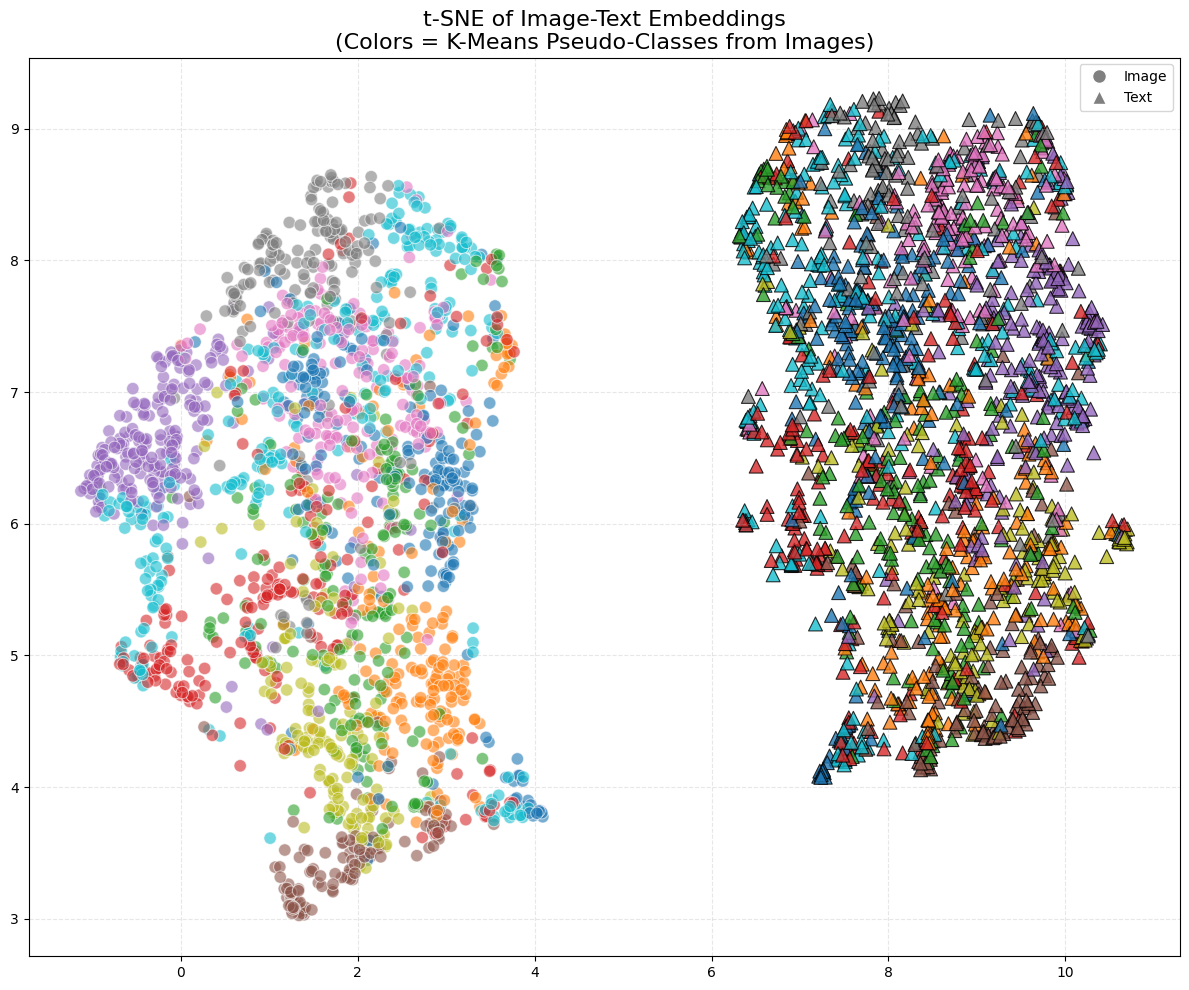

In [50]:
visualize_embeddings(
    all_image_features.numpy(), all_text_features.numpy(), num_clusters=10, num_samples=2_500
)